# Feature Engineering 

It is a technique of machine learning which helps us to create new features or transforming the existing feature to make the data more informative for machine learning model

In this we have Four steps:-
1. Feature Transformation
2. Feature Construction
3. Feature Selection
4. Feature Extraction

## 1. Feature Transformation
It is a part of feature engineering in this we transform the feature from original feature without changing the original information. It improves the performance of ml model while training.
* It also have 4 parts:-
1. Feature Scaling
2. Outlier Detection
3. Handling Categorical Variables
4. Missing Value imputation

### 1.1 Feature Scaling
It is technique which transform the feature where mean is 0 and standard deviation is 1. ( Ye datapoint ko center me lekar aata hai jiska mean = 0 and std = 1 hoga)
- We have diff. type of scaling 
1. Standardization (Z-Score)
2. Noramalization (MinMax Scaler)
3. MeanAbs Scaling
4. Robust Scaling

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
print("Imp Libarary are imported!!")

In [ ]:
# Take Example of Age Column of titanic dataset
df = pd.read_csv("social_network_ads.csv")
print("DataFrame Loaded")

In [ ]:
df.head()
# Purchased 0 = NO 1= YES

#### Before Scaling

In [ ]:
df.head()
sns.countplot(x = df['Age'].head(20))

In [ ]:
sns.scatterplot(x=df["Age"], y = df['EstimatedSalary'], hue = df['Purchased'])

## We perfom scaling after train_test_split but now for practice we only check here it working..

#### a) Standard Scaler

In [ ]:
scaler = StandardScaler()
# df['Age_Scaled'] = scaler.fit_transform(df[['Age']])
# df['EstimatedSalary_Scaled'] = scaler.fit_transform(df[['EstimatedSalary']])

#### After Scaling 

In [ ]:
df.head()

In [ ]:
fig = plt.figure(figsize=(6,5))
sns.scatterplot(x=df["Age_Scaled"], y = df['EstimatedSalary_Scaled'], hue = df['Purchased'])
plt.title("After Scaling")


After Scaling u can see the data will digest under -2.5 to 2.5 ("Estimated Salary") and -2.0 to 2.0 ("Age"), but the distribution of data remains same.Befoe scaling our salary in thousands now 0.5, 1.0 etc. It's good for algo which is scale sensitive and improve the performance

#### b) Normalization (MinMax Scaler)

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['Age_Scaled'] = scaler.fit_transform(df[['Age']])
df['EstimatedSalary_Scaled'] = scaler.fit_transform(df[['EstimatedSalary']])

#Formula:- x' = x - xmin/xmax - xmin

In [ ]:
df.head()

In [ ]:
fig = plt.figure(figsize=(6,5))
sns.scatterplot(x=df["Age_Scaled"], y = df['EstimatedSalary_Scaled'], hue = df['Purchased'])
plt.title("After Scaling")



In this Normalization data is squizzed between in range [0,1] like a cuboid container.You can see without scaling salary in thousand now in 0-1 range and age also it is diff from standard scaler here range is fixed. where not in standard scaler we convert the data into cetrical data
* Where we know the min and max of numerical data here it is apply before it ask himself the feature need scaling or not.


#### c) Robust Scaling

In [ ]:
from sklearn.preprocessing import RobustScaler
scaler = RobustScaler()
df['Age_Scaled'] = scaler.fit_transform(df[['Age']])
df['EstimatedSalary_Scaled'] = scaler.fit_transform(df[['EstimatedSalary']])

In [ ]:
fig = plt.figure(figsize=(6,5))
sns.scatterplot(x=df["Age_Scaled"], y = df['EstimatedSalary_Scaled'], hue = df['Purchased'])
plt.title("After Scaling")



When our data has outliers then we apply Robust Scaler 
- Formula:- x' = x - median/IQR

# 1.2 Handling Categorical Values
In this we transform the categorical values into numerical values because ml model works on number it doesn't understand the string. In Encoding Categorical we have two types:-
1. Nominal:- In this type, dataset have input columns which inlcude only categories, here oreder are not important like ex-> gender ( male, female), purchase (yes, no). Here order does not matter. We can handle this type column with OneHot Encoder class of sklearn
2. Ordinal:- In this type, data have inpute columns which include categories with the priority order, like ex-> education(postgraduate, highschool, undergraduate etc) in education we have order like pg>ug>hs, pg have high priority, hg have less priority then pg and school have low priority all of them. We can handle this type column using OrdinalEncoder class of sklearn.
* For Output variable we use LabelEncoder for the target variable. Ex-> purchase, we know it is nominal category column but according to rule we use for this target column Only LabelEncoder Always.

### Ordinal Encoder & Label Encoder

In [ ]:
# First we import all important library
import numpy as np
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
print("Library imported")


In [ ]:
#Load Dataset
df = pd.read_csv("Employee.csv")
df2 = pd.read_csv("pdd.csv")
df.info()
df2.info()

In [ ]:
df.head(20)

In [ ]:
df2.head(10)

In this dataset we have Education column which is ordinal. Now we apply ordinal encoding

In [ ]:
# Now we perform the train_test_split
X_train,X_test,y_train,y_test = train_test_split(df.iloc[:,0:1],df.iloc[:,-1], test_size=0.2)
A_train,A_test,b_train,b_test = train_test_split(df2.iloc[:,1:9],df2.iloc[:,-2], test_size=0.2)

In [ ]:
X_train

In [ ]:
b_train

In [ ]:
# Initialize the Ordinal Encoder object 
oe = OrdinalEncoder(categories=[['Bachelors','Masters','PHD']])
X_train  = oe.fit_transform(X_train)
le = LabelEncoder()
b_train = le.fit_transform(b_train)

In [ ]:

X_test = oe.transform(X_test)
b_test = le.transform(b_test)

In [ ]:
oe.categories_

In [ ]:
print(b_train)

In [ ]:
print(b_test)
print(le.classes_)

In [ ]:
print(X_train)

In [ ]:
print(X_test)

### One Hot Encoder

In [ ]:
df.head()

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(df[['City','Gender','Age','JoiningYear']],df.iloc[:,-1], test_size=0.2)
print(X_train.shape,X_test.shape,y_train.shape, y_test.shape)

In [ ]:
X_train

In [ ]:
X_test

In [ ]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(drop='first')

In [ ]:
X_train_new = ohe.fit_transform(X_train[['Gender','City']]).toarray()
X_test_new = ohe.transform(X_test[['Gender','City']]).toarray()

In [ ]:
X_train_new

In [ ]:
print(X_train_new.shape, X_test_new.shape)

In [ ]:
np.hstack((X_train[['Age','JoiningYear']].values,X_train_new)).shape

### Why Encoding is neede?
1. Most Ml algo work on numerical values as input (eg. KNN, SVM, Linear Regression, Neural Network etc.)
2. With the help of encoding we easily convert our categorical column/data into numeric before the model injection.
3. Diff. Encoding is used with different dependecy types of categorical values and Algo's

### We practice about encoding just above of the cell and learn about encoding, working with different encoding (like OneHotEncoder, LabelEncoder, OrdinalEncoder etc.). We perform different encoder for differnt type of column one by one so it's a very long process and hactic, so we use now Transformer Class of sklearn.

# Transformer
#### It is a class of sklearn.compose that help to create multiple transformer and apply scaling, and encoding at a single line of code. It saves our time and decrease the lenght of code. It is very useful for ml engineer which work with real dataset of company (those data incluede max no. of rows and column and messy data)

### Syntax of Transformer

In [ ]:
'''ColumnTransformer(transformers=[
                                ('name1',transformer1, columns1),
                                ('name2',transformer2, columns2),
                                ........,
                                ('namen',transformern, columnsn)],
                                remainder = "drop"/"passthrough")
'''

##### Where,
* transformers = List of (name, transformer, columns)
* name = any string (for reference)
* transformer = Preprocessing object (eg. MinMaxScaler, OneHotEncoder etc.)
* columns = list of columns names or indices, where you can aplly these effect.
* remainder = default "drop" -> it drop the unusual column, "passthrough" -> keeps unused columns without transformation.

#### Example of Transformer using dummy data

In [ ]:
import pandas as pd
import numpy as np
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split

print("Libraries are importes")

In [ ]:
# Import the Sample Data 
df = pd.read_csv('sample.csv')
print("Dataset Loaded Successfully")

In [ ]:
df.info()

#### We can analyze the dataset in the dataset total 5 columns of two types of datatype 2 are numerical and 3 are object, in this City & Gender are nominal category, salary and age are numericals.

In [ ]:
df.head()

In [ ]:
# Now start the process

#1. Apply Train Test apply process
X = df.iloc[:,0:4]
y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,random_state=42)

#2. Define column list
categorical = ['Gender','City']
numerical = ['Age','Salary']
categorical2 = ['Experience_level']

#3. Create transformer
cat1_transformer = OneHotEncoder(handle_unknown='ignore')

num_transformer = StandardScaler()

#4. Create Column Transformer 
preprocessor = ColumnTransformer(transformers=[
    ('Categorical1',cat1_transformer,categorical),
    
    ('Numerical',num_transformer,numerical)
],remainder='drop')

#. Fit & Transform
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)


In [ ]:
print(X_train_transformed)

In [ ]:
cat_fea = preprocessor.named_transformers_['Categorical1'].get_feature_names_out(categorical)
all_fea = numerical + list(cat_fea)

print(all_fea)

In [ ]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)

y_test_encode = le.transform(y_test)

In [ ]:
print(y_train_encoded)

##### This is complete process of transformer, you can analyze we can easily perform the transformer at a single time and single call. It is very usefull I like it very much

## Like ColumnTransformer we have Pipeline class in sklearn.compose, which helps us to create a pipeline use transformers we dont need write code one by one like first do scalind, then do encoding, train_test_split etc...

# *Pipeline


It is used to chain multiple steps of preprocessing and model, each steps run in sequence. It helps us code clean, modular and reprocible. Useful for applying transformation to trainig and testing data(avoid leakage)

#### Syntax

In [ ]:
'''
from sklearn.pipeline import Pipeline

pipe = Pipeline(steps = [
                        ('step1_name',transformer1),
                        ('step2_name',transformer2),
                        ............................
                        ('Model',estimator)
])

where, steps = list of (step_name, object) tuple
name = string for reference,
object = transformer (eg. Scaler, OneHotEncoder for text), estimator (eg. LogisticRegression)
last step always be model (estimator)
'''


##### Now create a complete pipeline using sklearn.pipeline

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, FunctionTransformer, PowerTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, classification_report
from sklearn.impute import SimpleImputer
from sklearn import set_config
from sklearn.feature_selection import chi2,SelectKBest

set_config(display='diagram')
print("All libraries are import ")
print("Setup is Ready, Now you do your job")

All libraries are import 
Setup is Ready, Now you do your job


In [ ]:
# Load Data
df = pd.read_csv('tested.csv')
df.head()

In [ ]:
df.info()

In [ ]:
print(df.shape)
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)
print(df.shape)

In [ ]:
df.info()

In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']

print(X.shape)
print(y.shape)
#split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state=42,stratify=y)

print(X_train.shape)
print(y_train.shape)
print(X_train)


In [ ]:
#1. Imputation Transformer
trf1 = ColumnTransformer(transformers=[
    ('age_imputer',SimpleImputer(),[2]),
    ('fare_imputer',SimpleImputer(),[5])
],remainder='passthrough')

#2. Encoding Transformer
trf2 = ColumnTransformer(transformers=[
    ('ohe_sex_embarked',OneHotEncoder(sparse_output=False,handle_unknown='ignore'),[1,6])

],remainder='passthrough')

#3. Scaling Transformer
trf3 = ColumnTransformer(transformers=[
    ('scale',MinMaxScaler(),slice(0,10))
])

#4. Feature selection
trf4 = SelectKBest(score_func=chi2, k=4)

#5. Train the model 
trf5 = LogisticRegression()

#6. Create PipeLine 
pipe = Pipeline(steps=[
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3),
    ('trf4',trf4),
    ('trf5',trf5)
])

'''
Note:- Pipeline vs make_pipeline
1.Alternate Syntax :- pipe = make_pipeline(trf1,trf2,trf3,trf4)
'''

# train
pipe.fit(X_train,y_train)

### Explore the pipeline

In [ ]:

pipe.named_steps
# pipe.named_steps['trf1'].transformers_[0][1].statistics_ -> it give the output of the 0th index of transformer and 1th index of object and .statetistics__ give the mean value which is filled in null or empty column

In [ ]:
print(list(y_test))

In [ ]:
# Predict 
y_pred = pipe.predict(X_test)

accuracy_score(y_test,y_pred)


## *Mathematical Transformation:- 
With the help of thi transforamtion, if data is non-normal distribute then transform it in normal distributed data, It change the scale,relation of features and distribution but not change the behaviour/meaning of feature only its representataion. We have two type of mathematical transformation :-
1. Functional Transformation
2. Power Transformation



### 1.Functional Transformation:- Apply a custom function as a transformer using pipeline class of sklearn. It has diff types which r as follows

##### Syntax

In [ ]:
'''
FunctionTransformer(func = np.log1p)
'''


In [ ]:
df.head()

#### 1.1 Log Transformation

In [ ]:
df = pd.read_csv('Titanic-Dataset.csv')

df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

df.head(20)
print(df.shape)

In [ ]:
X = df.drop(columns=['Survived'])
y = df['Survived']

In [ ]:
print(X.shape)
print(y.shape)

In [ ]:
# Now train and split our data
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

#### Before transformation

In [ ]:
# Use LogisticRegression Model

pipe1 = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('age', SimpleImputer(), ['Age']),
        # here we don't use here function transformation
        ('numeric', SimpleImputer(), ['Pclass', 'SibSp', 'Parch','Fare']),
        ('categorical', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), ['Sex', 'Embarked'])
    ])),
    ('scale', MinMaxScaler()),
    ('select', SelectKBest(score_func=chi2, k=6)),# we use here feature selection on k=4 it give score = .76  and without it give .79 means there impact is negative on our model.
    ('model', LogisticRegression(max_iter=1000))
])

pipe1.fit(X_train, y_train)


In [ ]:
y_pred1 = pipe1.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred1))

print("\nClassification Report:")
print(classification_report(y_test, y_pred1))


### After FunctionTransformation

In [ ]:
# Use LogisticRegression Model

pipe2 = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('age', SimpleImputer(), ['Age']),
        ('fare', Pipeline(steps=[
            ('imputer', SimpleImputer()),
            ('log', FunctionTransformer(np.log1p, validate=False))
        ]), ['Fare']),
        ('numeric', SimpleImputer(), ['Pclass', 'SibSp', 'Parch']),
        ('categorical', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), ['Sex', 'Embarked'])
    ])),
    ('scale', MinMaxScaler()),
    # ('select', SelectKBest(score_func=chi2, k=4)),
    ('model', LogisticRegression(max_iter=1000))
])

pipe2.fit(X_train, y_train)


In [ ]:
y_pred2 = pipe2.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred2))

print("\nClassification Report:")
print(classification_report(y_test, y_pred2))


In [ ]:
# Using DecisionTreeClassifier model.

    

pipe3 = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(transformers=[
        ('age', SimpleImputer(), ['Age']),
        ('fare', Pipeline(steps=[
                    ('imputer', SimpleImputer()),
                    ('log', FunctionTransformer(np.sqrt, validate=False))
                ]), ['Fare']),
        ('numeric', SimpleImputer(), ['Pclass', 'SibSp', 'Parch']),
        ('categorical', OneHotEncoder(
            handle_unknown='ignore',
            sparse_output=False
        ), ['Sex', 'Embarked'])
    ])),
    ('scale', MinMaxScaler()),
    #('select', SelectKBest(score_func=chi2, k=4)),
    ('model', DecisionTreeClassifier())
])

pipe3.fit(X_train, y_train)

In [ ]:
y_pred3 = pipe3.predict(X_test)


print("Accuracy:", accuracy_score(y_test, y_pred3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred3))


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    pipe1,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean CV Accuracy:", scores.mean())

In [ ]:
scores = cross_val_score(
    pipe2,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean CV Accuracy:", scores.mean())

In [ ]:
scores = cross_val_score(
    pipe3,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
)

print(scores)
print("Mean CV Accuracy:", scores.mean())

### We use three pipe(pipe1, pipe2 and pipe3):-
1. We use pipe1 without function transformer (log1p) then its avrg score is 77% using LogisticRegression.
2. We use pipe2 with function transformer (log1p) then its mean score is 79% using LogisticRegression.
3. We use pipe3 with function transformer (log1p) then its mean score is 75% using DecisionTree. We change log1p to sqr and sqrt but it still 75%.
* Based on our training we got not all time functiontransformation is profitable for our model on decisiontree model it not working. before and after it show same accuracy but in logistic regression it improves.

### 2.PowerTransformer

In [2]:
df = pd.read_csv('concrete_data.csv')
print("Dataset Load Successfully!")

Dataset Load Successfully!


In [3]:
df.head(10)
print(df.shape)

(1030, 9)


In [3]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


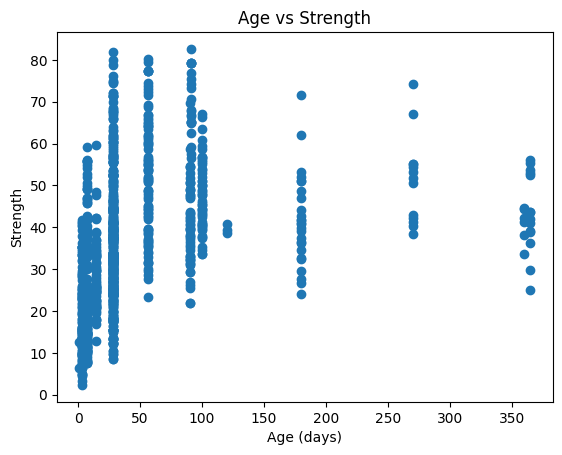

In [4]:
import matplotlib.pyplot as plt

plt.scatter(df['Age'], df['Strength'])
plt.xlabel('Age (days)')
plt.ylabel('Strength')
plt.title('Age vs Strength')
plt.show()

In [6]:
X = df.drop(columns=['Strength'])
y = df['Strength']

In [ ]:

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)


(824, 8)
(824,)


In [8]:
num_cols = df

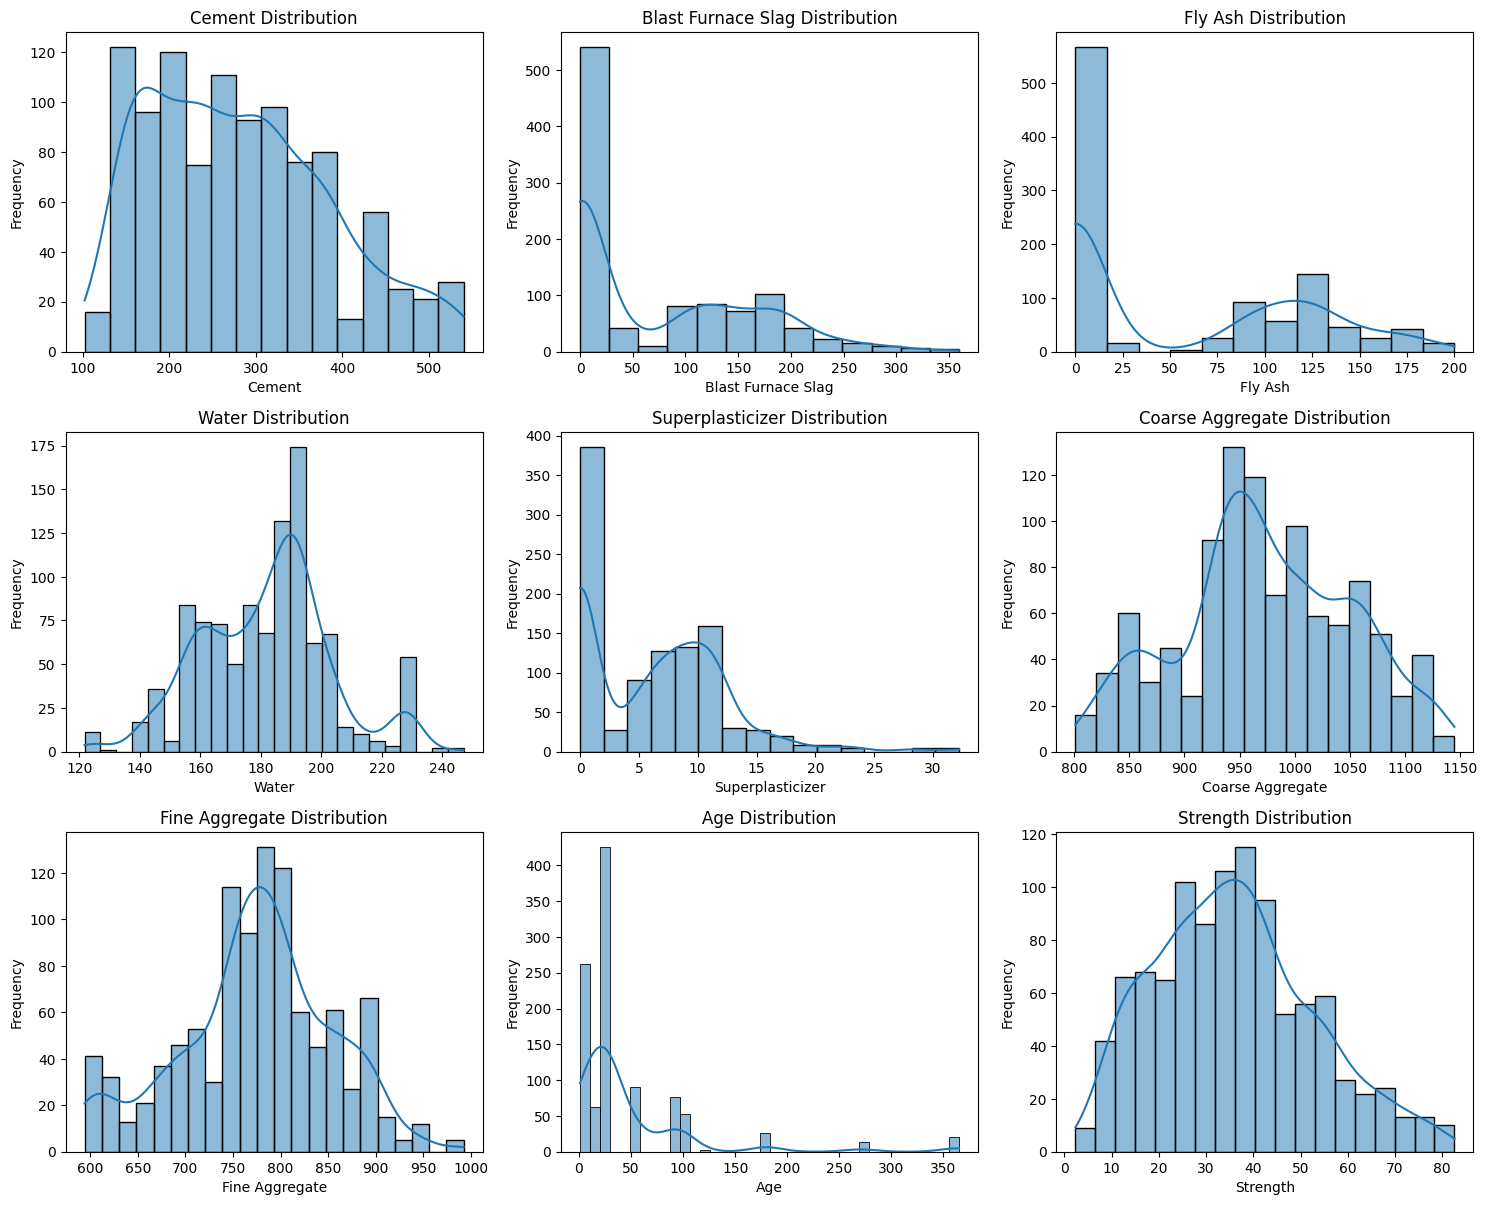

In [9]:
n_cols = 3
n_rows = (len(num_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(15, 4 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df[col],
        kde=True,
        ax=axes[i]
    )

    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Empty plots remove
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [10]:
num_cols = df.select_dtypes(include='number').columns

skewness = df[num_cols].skew().sort_values(ascending=False)

print(skewness)

Age                   3.269177
Superplasticizer      0.907203
Blast Furnace Slag    0.800717
Fly Ash               0.537354
Cement                0.509481
Strength              0.416977
Water                 0.074628
Coarse Aggregate     -0.040220
Fine Aggregate       -0.253010
dtype: float64


In [11]:
skewed_cols = skewness[abs(skewness) > 1].index

print("Highly skewed columns:")
print(skewed_cols)

Highly skewed columns:
Index(['Age'], dtype='object')


In [12]:
df.isnull().sum()
print(df.shape)

(1030, 9)


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

#### -Without PowerTransformer

In [14]:
pipe1 = Pipeline(steps = [
    ('scale', MinMaxScaler()),
    #('select', SelectKBest(score_func=chi2, k=4)),
    ('model', LinearRegression())
])

pipe1.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Cement','Blast Furnace Slag','Fly Ash',...,'Coarse Aggregate', 'Fine Aggregate','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value


In [ ]:
y_pred1 = pipe1.predict(X_test)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred1)
mse = mean_squared_error(y_test, y_pred1)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred1)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


MAE  : 7.745559243921429
MSE  : 95.97094009110684
RMSE : 9.796475901624362
R²   : 0.6275531792314848


#### -With PowerTransformer (method=yeo-johnson)

In [16]:
pipe2 = Pipeline(steps = [
    ('processpr',ColumnTransformer(transformers=[('age',PowerTransformer(method='yeo-johnson',standardize=True),['Age'])],remainder='passthrough')),
    ('scale', MinMaxScaler()),
    ('model', LinearRegression())
])

pipe2.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processpr', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Cement','Blast Furnace Slag','Fly Ash',...,'Coarse Aggregate', 'Fine Aggregate','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [ ]:
y_pred2 = pipe2.predict(X_test)

mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred2)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


MAE  : 5.328939990999225
MSE  : 44.95947436117571
RMSE : 6.705182649352343
R²   : 0.825519961841083


#### With PowerTransformer (method=box-cox)

In [21]:
pipe3 = Pipeline(steps = [
    ('processpr',ColumnTransformer(transformers=[('age',PowerTransformer(method='box-cox',standardize=True),['Age'])],remainder='passthrough')),
    ('scale', MinMaxScaler()),
    ('model', LinearRegression())
])

pipe3.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processpr', ...), ('scale', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Cement','Blast Furnace Slag','Fly Ash',...,'Coarse Aggregate', 'Fine Aggregate','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [20]:
y_pred3 = pipe3.predict(X_test)

mae = mean_absolute_error(y_test, y_pred3)
mse = mean_squared_error(y_test, y_pred3)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred3)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


MAE  : 5.330777418936888
MSE  : 45.08889900636812
RMSE : 6.71482680389957
R²   : 0.8250176869067618


#### Without LinearRegression without PowerTransformer, In this we use DecisionTreeRegressor

In [22]:
pipe4 = Pipeline(steps = [
    # ('processpr',ColumnTransformer(transformers=[('age',PowerTransformer(method='box-cox',standardize=True),['Age'])],remainder='passthrough')),
    # ('scale', MinMaxScaler()),
    ('model', DecisionTreeRegressor())
])

pipe4.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Cement','Blast Furnace Slag','Fly Ash',...,'Coarse Aggregate', 'Fine Aggregate','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the mi

In [24]:
y_pred4 = pipe4.predict(X_test)

mae = mean_absolute_error(y_test, y_pred4)
mse = mean_squared_error(y_test, y_pred4)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred4)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


MAE  : 4.260145631067961
MSE  : 42.73436262135922
RMSE : 6.537152485705012
R²   : 0.834155240317699


#### Insight:
1. Without PowerTransformer linear regression give poor results on this test.
2. With PowerTransformer linear regression give better results and yeo-johnson is better than box-cox we find this on analyze.
3. Most important without PowerTransformer we can use DecisionTreeRegressor give all over best result, because decision tree regressor not affected by the scales, or imbalancy of data.

In [16]:
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

In [17]:
X = df.drop(columns=['Strength'])
y = df['Strength']
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2, random_state=42)

print(X_train.shape)
print(y_train.shape)
X_train

(824, 8)
(824,)


,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age
995,158.6,148.9,116.0,175.1,15.0,953.3,719.7,28
507,424.0,22.0,132.0,178.0,8.5,822.0,750.0,28
334,275.1,0.0,121.4,159.5,9.9,1053.6,777.5,3
848,252.0,97.0,76.0,194.0,8.0,835.0,821.0,28
294,168.9,42.2,124.3,158.3,10.8,1080.8,796.2,3
...,...,...,...,...,...,...,...,...
87,286.3,200.9,0.0,144.7,11.2,1004.6,803.7,3
330,246.8,0.0,125.1,143.3,12.0,1086.8,800.9,14
466,190.3,0.0,125.2,166.6,9.9,1079.0,798.9,100
121,475.0,118.8,0.0,181.1,8.9,852.1,781.5,28


### Without Binning Encoding (Discretizer)

In [18]:
pipe1 = Pipeline(steps=[('First',MinMaxScaler()),('Model',LinearRegression())])

pipe1.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('First', ...), ('Model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Cement','Blast Furnace Slag','Fly Ash',...,'Coarse Aggregate', 'Fine Aggregate','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
Name,Type,Value


In [19]:
y_pred1 = pipe1.predict(X_test)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred1)
mse = mean_squared_error(y_test, y_pred1)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred1)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


MAE  : 7.745559243921429
MSE  : 95.97094009110684
RMSE : 9.796475901624362
R²   : 0.6275531792314848


### With Binning Encoding, stretegy = uniform

In [44]:
pipe2 = Pipeline(steps=[('processpr',ColumnTransformer(transformers=[('age',KBinsDiscretizer(n_bins=5, encode='ordinal',strategy='uniform'),[7])],remainder='passthrough')),
                        ('First',MinMaxScaler()),('Model',LinearRegression())])

pipe2.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processpr', ...), ('First', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Cement','Blast Furnace Slag','Fly Ash',...,'Coarse Aggregate', 'Fine Aggregate','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [45]:
y_pred2 = pipe2.predict(X_test)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred2)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


MAE  : 8.480414567260944
MSE  : 110.99945322710633
RMSE : 10.53562780412759
R²   : 0.5692300875428211


### With Binning Encoding, strategy = quantile

In [54]:
pipe2 = Pipeline(steps=[('processpr',ColumnTransformer(transformers=[('age',KBinsDiscretizer(n_bins=10, encode='ordinal',strategy='quantile'),[7])],remainder='passthrough')),
                        ('First',MinMaxScaler()),('Model',LinearRegression())])

pipe2.fit(X_train,y_train)

c:\Users\shekh\OneDrive\Documents\Machne Learning simplilearn\venv\Lib\site-packages\sklearn\preprocessing\_discretization.py:385: UserWarning: Bins whose width are too small (i.e., <= 1e-8) in feature 0 are removed. Consider decreasing the number of bins.
  warnings.warn(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('processpr', ...), ('First', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['Cement','Blast Furnace Slag','Fly Ash',...,'Coarse Aggregate', 'Fine Aggregate','Age']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('age', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of colu

In [55]:
y_pred2 = pipe2.predict(X_test)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred2)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


MAE  : 5.366148950857868
MSE  : 43.32524322187036
RMSE : 6.582191369283512
R²   : 0.8318621336657768


### With Binning Encoding, strategy = quantile

In [57]:
pipe2 = Pipeline(steps=[('processpr',ColumnTransformer(transformers=[('age',KBinsDiscretizer(n_bins=10, encode='ordinal',strategy='kmeans'),[7])],remainder='passthrough')),
                        ('First',MinMaxScaler()),('Model',LinearRegression())])

pipe2.fit(X_train,y_train)

y_pred2 = pipe2.predict(X_test)


from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred2)
mse = mean_squared_error(y_test, y_pred2)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred2)

print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R²   :", r2)


MAE  : 5.954549782999281
MSE  : 62.842763087896444
RMSE : 7.927342750751758
R²   : 0.7561179738556619


#### After perform these all encoding on age columns, analyze the quantile strategy is better than uniform and kmeans. But it not always give better result, its vary according to the dataset.